# 기후 민감도와 피드백

이 노트북은 올버니 대학교의 [Brian E. J. Rose](https://www.atmos.albany.edu/facstaff/brose/)가 작성한 [The Climate Laboratory](https://brian-rose.github.io/ClimateLaboratoryBook)의 일부입니다.

## 1. 복사 강제력 (Radiative Forcing)

### 개념

우리는 이전에 복사 강제력(Radiative Forcing) 개념을 본 적이 있습니다. 이것은 기후 시스템에 강제력 발생 인자(forcing agent)를 추가할 때, **지표면이 따뜻해질 기회를 얻기 전에** 발생하는 대기 상단(TOA) 에너지 수지의 단기적인 변화입니다.

표준 기준 강제력은 **대기 중 CO$_2$ 농도의 두 배 증가**입니다.

**복사 강제력 (Radiative Forcing)**은 W m$^{-2}$ 단위의 값으로, 시스템이 에너지를 **얻고 있을 때 양수**가 되도록 정의됩니다:

$$ \Delta R = \left(\text{ASR}_{2xCO2} - \text{OLR}_{2xCO2}\right) - \left(\text{ASR}_{ref} - \text{OLR}_{ref}\right)$$

$\Delta R$은 온실가스가 급격히 증가한 후 기후 시스템에 에너지가 축적되기 시작하는 비율을 나타내는 척도입니다. 단, *기후(즉, 온도)에 변화가 생기기 전*의 상황을 의미합니다.

### 단일 열 복사-대류 모델 설정하기

단일 열 복사-대류 모델(single-column Radiative-Convective model)을 설정하여, 이 열에 추가 CO$_2$를 주입할 때 어떤 변화가 발생하는지 자세히 살펴보겠습니다.

In [1]:
%matplotlib inline

# Install missing xarray backends if not already installed
import subprocess
import sys

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr


try:
    import netCDF4
    import pydap
    import metpy
except ImportError:
    print("Installing netCDF4 and pydap...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "netCDF4", "pydap","metpy"])
    print("Installation complete. Please rerun the cell.")



from metpy.plots import SkewT

url = 'http://apdrc.soest.hawaii.edu:80/dods/public_data/Reanalysis_Data/NCEP/NCEP/clima/pressure/air'
air = xr.open_dataset(url)
## The name of the vertical axis is different than the NOAA ESRL version..
ncep_air = air.rename({'lev': 'level'})
ncep_air





#  Take global, annual average
coslat = np.cos(np.deg2rad(ncep_air.lat))
weight = coslat / coslat.mean(dim='lat')
Tglobal = (ncep_air.air * weight).mean(dim=('lat','lon','time'))
#  Resuable function to plot the temperature data on a Skew-T chart
def make_skewT():
    fig = plt.figure(figsize=(9, 9))
    skew = SkewT(fig, rotation=30)
    skew.plot(Tglobal.level, Tglobal, color='black', linestyle='-', linewidth=2, label='Observations')
    skew.ax.set_ylim(1050, 10)
    skew.ax.set_xlim(-90, 45)
    # Add the relevant special lines
    skew.plot_dry_adiabats(linewidth=0.5)
    skew.plot_moist_adiabats(linewidth=0.5)
    #skew.plot_mixing_lines()
    skew.ax.legend()
    skew.ax.set_xlabel('Temperature (degC)', fontsize=14)
    skew.ax.set_ylabel('Pressure (hPa)', fontsize=14)
    return skew
#  and a function to add extra profiles to this chart
def add_profile(skew, model, linestyle='-', color=None):
    line = skew.plot(model.lev, model.Tatm - climlab.constants.tempCtoK,
             label=model.name, linewidth=2)[0]
    skew.plot(1000, model.Ts - climlab.constants.tempCtoK, 'o',
              markersize=8, color=line.get_color())
    skew.ax.legend()

# Get the water vapor data from CESM output
cesm_data_path = "http://thredds.atmos.albany.edu:8080/thredds/dodsC/CESMA/"
# For better performance if you can access the roselab_rit filesystem (e.g. from JupyterHub)
# cesm_data_path = "/roselab_rit/cesm_archive/"
atm_control = xr.open_dataset(cesm_data_path + "cpl_1850_f19/concatenated/cpl_1850_f19.cam.h0.nc")
# Take global, annual average of the specific humidity
weight_factor = atm_control.gw / atm_control.gw.mean(dim='lat')
Qglobal = (atm_control.Q * weight_factor).mean(dim=('lat','lon','time'))
#  Create the single-column model domain



import sys
!{sys.executable} -m pip install climlab
import climlab
print(climlab.__version__)
!{sys.executable} -m pip install git+https://github.com/climlab/climlab-rrtmg.git







/usr/local/lib/python3.12/dist-packages/xarray/coding/times.py:215: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)
/tmp/ipykernel_9141/3267447218.py:26: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  air = xr.open_dataset(url)


/usr/local/lib/python3.12/dist-packages/climlab/radiation/cam3.py:45: UserWarning: Cannot import and initialize compiled Fortran extension, CAM3 module will not be functional.
  warnings.warn('Cannot import and initialize compiled Fortran extension, CAM3 module will not be functional.')
/usr/local/lib/python3.12/dist-packages/climlab/convection/emanuel_convection.py:12: UserWarning: Cannot import EmanuelConvection fortran extension, this module will not be functional.
  warnings.warn('Cannot import EmanuelConvection fortran extension, this module will not be functional.')
/usr/local/lib/python3.12/dist-packages/climlab/convection/simplified_betts_miller.py:110: UserWarning: Cannot import SimplifiedBettsMiller fortran extension, this module will not be functional.
  warnings.warn('Cannot import SimplifiedBettsMiller fortran extension, this module will not be functional.')


0.9.2
  Cloning https://github.com/climlab/climlab-rrtmg.git to /tmp/pip-req-build-34a0qkq4
  Running command git clone --filter=blob:none --quiet https://github.com/climlab/climlab-rrtmg.git /tmp/pip-req-build-34a0qkq4
  Resolved https://github.com/climlab/climlab-rrtmg.git to commit 30c9e0b679151ee990e466f9defe5198b28d8172
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
#  Make a model on same vertical domain as the GCM
mystate = climlab.column_state(lev=Qglobal.lev, water_depth=2.5)
#  Build the radiation model -- just like we already did
rad = climlab.radiation.RRTMG(name='Radiation',
                              state=mystate,
                              specific_humidity=Qglobal.values,
                              timestep = climlab.constants.seconds_per_day,
                              albedo = 0.25,  # surface albedo, tuned to give reasonable ASR for reference cloud-free model
                             )
#  Now create the convection model
conv = climlab.convection.ConvectiveAdjustment(name='Convection',
                                               state=mystate,
                                               adj_lapse_rate=6.5,
                                               timestep=rad.timestep,
                                              )
#  Here is where we build the model by coupling together the two components
rcm = climlab.couple([rad, conv], name='Radiative-Convective Model')


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
rcm

먼저, 우리 참조 모델의 기본 CO$_2$ 양을 살펴보겠습니다:

In [4]:
rcm.subprocess['Radiation'].absorber_vmr['CO2']

0.000348

이는 348 백만분율(ppm)입니다. 우리 대기는 1980년대 후반 무렵에 이 농도 수준이었습니다.

CO$_2$ 교란의 영향을 살펴보기 전에, 우리는 기준 모델을 평형 상태까지 통합(적분)해야 합니다.

In [5]:
rcm.integrate_years(5)

Integrating for 1826 steps, 1826.2110000000002 days, or 5 years.
Total elapsed time is 4.999422301147019 years.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


우리는 에너지 균형에 가까워지고 있는가?

In [6]:
rcm.ASR - rcm.OLR

Field([-3.36797257e-11])

### RCM 내 섭동된 이산화탄소(CO2) 계산

In [7]:
# Make an exact clone with same temperatures
rcm_2xCO2 = climlab.process_like(rcm)
rcm_2xCO2.name = 'Radiative-Convective Model (2xCO2 initial)'

In [8]:
#  Check to see that we indeed have the same CO2 amount
rcm_2xCO2.subprocess['Radiation'].absorber_vmr['CO2']

0.000348

In [9]:
#  Now double it!
rcm_2xCO2.subprocess['Radiation'].absorber_vmr['CO2'] *= 2

In [10]:
#  and verify
rcm_2xCO2.subprocess['Radiation'].absorber_vmr['CO2']

0.000696

### 순간 복사 강제력 계산

복사 강제력(Radiative Forcing)의 가장 간단한 척도는 온도가 조절될 기회를 갖기 전에 에너지 수지(Energy Budget)에서 발생하는 즉각적인 변화입니다.

이를 얻으려면 `compute_diagnostics` 메서드를 호출해야 하지만, 순방향 시간 단계(forward timestep)는 아닙니다.

In [11]:
rcm_2xCO2.compute_diagnostics()

이제 단파 복사 (SW)와 장파 복사 (LW) 수지의 변화를 살펴보겠습니다.

In [12]:
rcm_2xCO2.ASR - rcm.ASR

Field([0.06274162])

In [13]:
rcm_2xCO2.OLR - rcm.OLR

Field([-2.11458541])

그렇다면 이산화탄소(CO2) 농도가 2배로 증가했을 때의 순간 복사 강제력(Instantaneous Radiative Forcing)은 얼마일까요?

In [14]:
DeltaR_instant = (rcm_2xCO2.ASR - rcm_2xCO2.OLR) - (rcm.ASR - rcm.OLR)
DeltaR_instant

Field([2.17732704])

이 모델에서 이산화탄소(CO2) 농도가 두 배로 증가했을 때의 복사 강제력(Radiative Forcing)은 2.18 W m$^{-2}$입니다.

위에서 볼 수 있듯이, 복사 강제력(Radiative Forcing)의 거의 대부분은 장파(longwave)에서 나타납니다. 우리는 CO$_2$를 추가함으로써 대기를 **광학적으로 더 두껍게** 만들었습니다.

이 점을 단순 회색 기체 모델(simple grey-gas model)에서 흡수율(absorptivity) / 방출률(emissivity) 매개변수 $\epsilon$을 증가시켰던 방식과 동일하게 생각해보세요.

### 대기 조정 복사 강제력 (Atmosphere-adjusted radiative forcing)

복사 강제력(Radiative Forcing)을 측정하는 이유는 특정 강제력 인자로부터 우리가 얼마나 많은 지구 온난화를 예상해야 하는지에 대한 정보를 얻기 위함입니다.

우리는 이 강제력과 관련된 **궁극적인** 온도 변화를 정량화하기 위해 모델을 사용해야 할 것입니다.

지구 표면은 대부분 물로 되어 있고 물은 열용량(heat capacity)이 크기 때문에, 대기 온도는 CO$_2$와 같은 강제력 인자에 반응하여 **매우 빠르게 변할 수 있지만**, 표면 온도는 데워지는 데 훨씬 더 오랜 시간이 걸릴 수 있습니다.

여기서 자세히 다루지는 않겠지만, 강제력 인자의 *궁극적인* 지구 온난화 영향을 측정하는 데 더 유용한 척도는 **대기가 추가 CO$_2$에 적응한 후** 그리고 **표면 온도를 고정한 채로** 대기 상단(TOA) 복사를 고려하는 것에서 비롯됩니다.

**대기 조정 강제력(atmosphere-adjusted forcing)**을 계산하기 위해, 우리는 모델을 시간 단계별로 진행시킬 것이지만, 지표 온도는 계속해서 기준 값으로 재설정할 것입니다:

In [15]:
rcm_2xCO2_adjusted = climlab.process_like(rcm_2xCO2)
rcm_2xCO2_adjusted.name = 'Radiative-Convective Model (2xCO2 atmosphere-adjusted)'
for n in range(1000):
    rcm_2xCO2_adjusted.step_forward()
    # hold surface temperature fixed
    rcm_2xCO2_adjusted.Ts[:] = rcm.Ts[:]

이제 우리는 CO$_2$ 농도 두 배 증가에 대한 대기 조정된 복사 강제력(atmosphere-adjusted radiative forcing)을 계산할 수 있습니다.

In [16]:
DeltaR_adjusted = (rcm_2xCO2_adjusted.ASR - rcm_2xCO2_adjusted.OLR) - (rcm.ASR - rcm.OLR)
DeltaR_adjusted

Field([4.21488759])

결과는 약 4.2 W m$^{-2}$입니다.

## 2. 평형 기후 감도 (피드백/되먹임 없음)

이제 우리는 이 양의 복사 강제력(Radiative Forcing)에 대한 반응으로 (궁극적으로) 얼마나 많은 온난화가 발생할지 질문합니다.

### 정의

우리는 **평형 기후 민감도** (약어로는 **ECS**, 또는 $\Delta T_{2xCO2}$로 표기)를 다음과 같이 정의합니다:

*대기 중 이산화탄소 농도가 두 배로 증가한 후, 행성 에너지 수지(planetary energy budget)의 균형을 맞추기 위해 필요한 전 지구 평균 표면 온도 상승.*

### 단일 열 RCM에서의 기후 변화

이제 우리의 단일 열 모델에서 평형 기후 민감도(ECS)를 계산해 봅시다:

In [17]:
rcm_2xCO2_eq = climlab.process_like(rcm_2xCO2_adjusted)
rcm_2xCO2_eq.name = 'Radiative-Convective Model (2xCO2 equilibrium)'
rcm_2xCO2_eq.integrate_years(5)

Integrating for 1826 steps, 1826.2110000000002 days, or 5 years.
Total elapsed time is 12.736753858124827 years.


In [18]:
# are we close to equilibrium?
rcm_2xCO2_eq.ASR - rcm_2xCO2_eq.OLR

Field([1.30455646e-11])

이전에 했던 방식을 따라, 결과를 멋진 Skew-T 차트에 그려 봅시다:

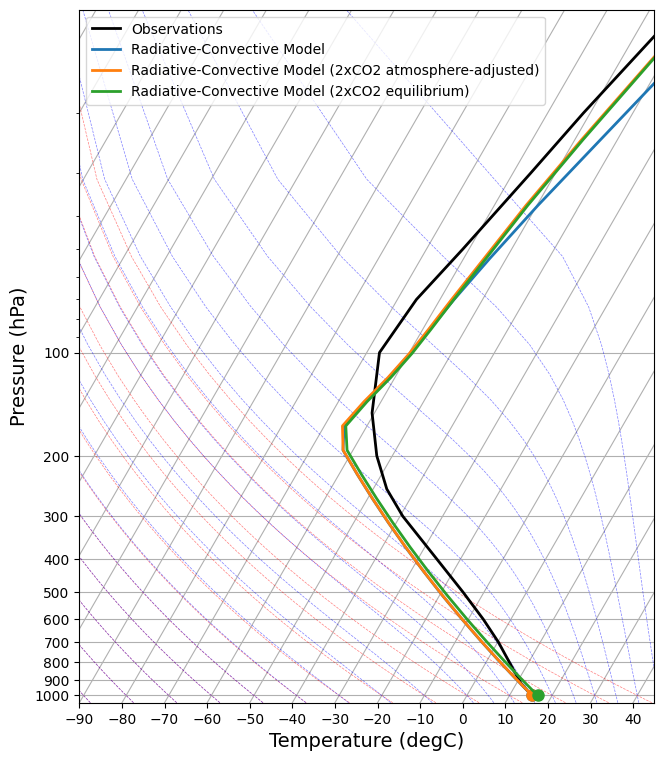

In [19]:
skew = make_skewT()
add_profile(skew, rcm)
add_profile(skew, rcm_2xCO2_adjusted)
add_profile(skew, rcm_2xCO2_eq)

### 변화를 더 잘 보기 위한 다른 시각화

우리는 두 배로 증가한 CO$_2$의 영향을 보기 위해 기준 RCM 대비 온도 **차이**를 그릴 수 있습니다.

여기서는 스키유-T(Skew-T) 선도에서처럼 고도(height)나 로그-압력(log-pressure) 대신 압력 좌표를 기준으로 그립니다. 둘 다 유효하지만, 수직 구조의 서로 다른 측면을 강조합니다.

/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2012: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.style_literal  = oneOf(
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2024: PyparsingDeprecationWarning: 'oneO

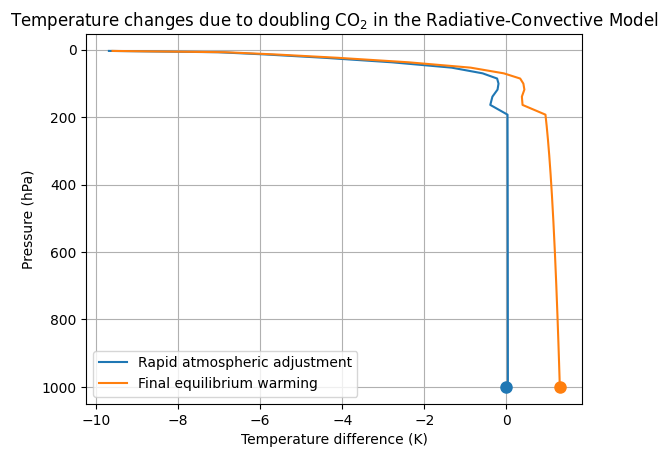

In [20]:
fig,ax = plt.subplots()

line = ax.plot(rcm_2xCO2_adjusted.Tatm - rcm.Tatm, rcm.lev, label='Rapid atmospheric adjustment')[0]
ax.plot(rcm_2xCO2_adjusted.Ts - rcm.Ts, 1000., 'o', markersize=8, color=line.get_color(), )

line = ax.plot(rcm_2xCO2_eq.Tatm - rcm.Tatm, rcm.lev, label='Final equilibrium warming')[0]
ax.plot(rcm_2xCO2_eq.Ts - rcm.Ts, 1000., 'o', markersize=8, color=line.get_color(), )

ax.invert_yaxis()
ax.set_xlabel('Temperature difference (K)')
ax.set_ylabel('Pressure (hPa)')
ax.grid()
ax.legend()
ax.set_title('Temperature changes due to doubling CO$_2$ in the Radiative-Convective Model');

이 두 그래프에서 무엇이 보이나요? 무엇이 달라졌나요?

### 평형 기후 민감도 (ECS) 계산하기

이는 단순히 표면 온도의 차이입니다:

In [21]:
ECS_nofeedback = rcm_2xCO2_eq.Ts - rcm.Ts
ECS_nofeedback

Field([1.29984831])

이 모델에서 이산화탄소(CO$_2$) 농도를 두 배로 늘리면 평형 상태에서 약 1.3 K의 온난화가 발생합니다.

에너지 수지는 어떻게 될까요?

모델이 새로운 평형 상태에 도달할 때까지 워밍업(warm up)하도록 두었다는 점을 기억하세요!

두 평형 상태(CO$_2$ 농도 두 배 증가 전후) 간의 차이를 살펴보면, 단파(SW)와 장파(LW) 복사에서 매우 작고 상쇄되는 변화만 발견됩니다.

In [22]:
rcm_2xCO2_eq.OLR - rcm.OLR

Field([0.05080282])

In [23]:
rcm_2xCO2_eq.ASR - rcm.ASR

Field([0.05080282])

우리가 방금 계산한 1.3 K 민감도는 *이산화탄소(CO$_2$)로 인한 온난화에 대한 반응으로 다른 변화(피드백)가 전혀 없을 경우 겪게 될 온난화입니다!*

### 무피드백 반응

우리는 방금 피드백이 없는 모델에 대해 복사 강제력(Radiative Forcing) $\Delta R$ (단위: W m$^{-2}$)으로 인해 발생하는 평형 온난화 $\Delta T_0$ (단위: K)를 계산했습니다.

**피드백 없는 기후 반응 매개변수**(no-feedback climate response parameter) $\lambda_0$를 다음과 같이 정의해 봅시다.

$$ \lambda_0 = \frac{\Delta R}{\Delta T_0 } $$

위에서 도출한 수치들을 가지고,

In [24]:
lambda0 = DeltaR_adjusted / ECS_nofeedback
lambda0

Field([3.24259958])

무피드백 기후 반응 매개변수는 $\lambda_0 = 3.2$ W m$^{-2}$ K$^{-1}$ 입니다.

우리 모델이 간과한 중요한 과정들은 무엇입니까?

## 3. 되먹임(Feedback) 개념

이 개념은 전기 공학에서 빌려왔습니다. 여러분 모두 이 용어를 들어보거나 사용해 본 적이 있을 테지만, 오늘은 좀 더 정확한 방식으로 접근해보고자 합니다.

되먹임은 시스템의 작용으로 생성된 결과(출력)의 일부가 입력에 추가되어 그 결과(출력)를 변경할 때 발생합니다.

![피드백 루프 스케치](https://github.com/baekmin/ClimateLaboratoryBook/blob/main/images/feedback_sketch.png?raw=1)

루프 시스템의 결과는 루프 내 이득(gain)의 부호(이를 $f$로 나타냅니다)에 따라 해당 과정의 **증폭** 또는 **감쇠**가 될 수 있습니다.

우리는 증폭 피드백을 **양의**($f>0$), 감쇠 피드백을 **음의**($f<0$) 피드백이라고 칭합니다.

여기에서 "과정"을 전체 기후 시스템으로 생각할 수 있으며, 이 시스템은 양의 피드백과 음의 피드백의 많은 사례를 포함하고 있습니다.

### 예시: 수증기 피드백

대기가 수증기를 붙잡는 능력(포화 비습)은 온도에 따라 지수적으로 증가합니다. 따라서 온난화는 습윤화(더 많은 수증기)를 동반하며, 이는 강화된 수증기 온실 효과 때문에 더 많은 온난화로 이어집니다.

**긍정적 또는 부정적 피드백?**

### 예시: 얼음-알베도 피드백

더 낮은 기온은 얼음과 눈으로 덮인 지역의 확장을 초래하며, 이는 물과 식생보다 더 반사율(reflective)이 높은 경향이 있습니다. 이로 인해 흡수되는 태양 복사(solar radiation)가 감소하고, 이는 더 많은 냉각으로 이어집니다.

**양의 피드백인가, 음의 피드백인가?**

*피드백의 부호는 온난화(warming)에 대해 이야기하든 냉각(cooling)에 대해 이야기하든 동일하다는 점을 명확히 이해해야 합니다.*

## 4. 기후 피드백(Climate feedback): 몇 가지 정의

우리는 초기 복사 강제력(radiative forcing)으로 시작하여 다음과 같은 응답을 얻습니다.

$$ \Delta T_0 = \frac{\Delta R}{\lambda_0} $$

이제 피드백 과정이 있을 때 어떤 일이 발생하는지 고려해 봅시다. 구체적인 예시로, **수증기 피드백(water vapor feedback)**을 들어보겠습니다. 기온이 1도 상승할 때마다 온실 효과는 추가적으로 증가하며, 이에 따라 시스템에 추가적인 에너지가 더해집니다.

이 추가 에너지를 다음과 같이 표기해 봅시다:

$$ f \lambda_0 \Delta T_0 $$

여기서 $f$는 **피드백량(feedback amount)**으로, 출력의 어느 부분이 입력으로 다시 추가되는지를 나타내는 숫자입니다. $f$는 $-\infty$와 +1 사이의 값이어야 합니다.

수증기 피드백의 경우, $f$는 양수(0과 +1 사이)입니다. 즉, 이 과정은 원래의 복사 강제력(radiative forcing)에 추가 에너지를 더합니다.

전체 '입력'에 포함된 에너지의 양은 이제 다음과 같습니다.

$$ \Delta R + f \lambda_0 \Delta T_0 $$

또는

$$ (1+f) \lambda_0 \Delta T_0 $$

하지만 이제 다음 순환 고리(loop)를 고려해야 합니다. 추가 에너지의 $f$ 비율이 입력 값에 다시 더해져, 다음을 얻게 됩니다.

$$ (1+f+f^2) \lambda_0 \Delta T_0 $$

이러한 과정은 계속 반복되며 다음 무한 급수로 이어집니다.

$$ (1+f+f^2+f^3+ ...) \lambda_0 \Delta T_0 = \lambda_0 \Delta T_0 \sum_{n=0}^{\infty} f^n $$

질문: 만약 $f=1$이라면 어떤 일이 발생할까요?

마침 이 무한 급수는 정확한 해를 가집니다.

$$ \sum_{n=0}^{\infty} f^n = \frac{1}{1-f} $$

따라서 피드백의 모든 효과를 포함한 전체 반응은 실제로 다음과 같습니다.

$$ \Delta T = \frac{1}{1-f} \Delta T_0 $$

이것은 때때로 다음과 같이 쓰이기도 합니다:

$$ \Delta T = g \Delta T_0 $$

여기서

$$ g = \frac{1}{1-f} = \frac{\Delta T}{\Delta T_0} $$

는 **시스템 이득(system gain)**이라고 불리며, 이는 (모든 피드백을 포함한) 실제 온난화와 피드백이 없을 경우의 온난화 비율을 나타냅니다.

그래서 만약 전체 피드백이 양수라면, `$f>0$` 이고 `$g>1$` 입니다.

그러면 만약 전체 피드백이 음수라면요?

## 5. 복사-대류 모델에서의 수증기 피드백

자연에서 복잡한 GCM(기후대순환모델)에서와 마찬가지로, 기온이 상승함에 따라 수증기는 증가하는 경향을 보입니다.

이것의 주된 이유는 **포화 비습(saturation specific humidity)**(즉, 공기가 최대로 포함할 수 있는 수증기의 양)이 **온도에 따라 크게 증가하기 때문입니다.**

우리는 단일 기둥 모델(column model)에서 기둥의 온도가 상승할 때 **상대 습도가 일정하게 유지된다고 가정함으로써** 이러한 효과를 **매개변수화(parameterize)**할 수 있습니다.

In [25]:
#  actual specific humidity
q = rcm.subprocess['Radiation'].specific_humidity
#  saturation specific humidity (a function of temperature and pressure)
qsat = climlab.utils.thermo.qsat(rcm.Tatm, rcm.lev)
#  Relative humidity
rh = q/qsat

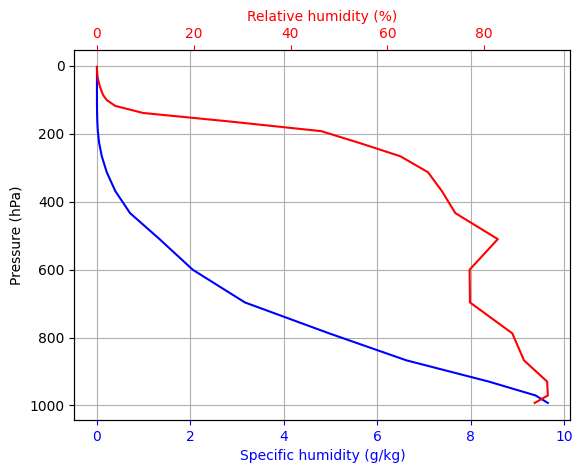

In [26]:
#  Plot relative humidity in percent
fig,ax = plt.subplots()
ax.plot(q*1000, rcm.lev, 'b-')
ax.invert_yaxis()
ax.grid()
ax.set_ylabel('Pressure (hPa)')
ax.set_xlabel('Specific humidity (g/kg)', color='b')
ax.tick_params('x', colors='b')
ax2 = ax.twiny()
ax2.plot(rh*100., rcm.lev, 'r-')
ax2.set_xlabel('Relative humidity (%)', color='r')
ax2.tick_params('x', colors='r')

### 고정된 상대 습도를 가진 복사-대류 모델

In [28]:
rcm_2xCO2_h2o = climlab.process_like(rcm_2xCO2)
rcm_2xCO2_h2o.name = 'Radiative-Convective Model (2xCO2 equilibrium with H2O feedback)'

In [29]:
for n in range(2000):
    # At every timestep
    # we calculate the new saturation specific humidity for the new temperature
    #  and change the water vapor in the radiation model
    #  so that relative humidity is always the same
    qsat = climlab.utils.thermo.qsat(rcm_2xCO2_h2o.Tatm, rcm_2xCO2_h2o.lev)
    rcm_2xCO2_h2o.subprocess['Radiation'].specific_humidity[:] = rh * qsat
    rcm_2xCO2_h2o.step_forward()

In [30]:
# Check for energy balance
rcm_2xCO2_h2o.ASR - rcm_2xCO2_h2o.OLR

Field([-1.73180524e-07])

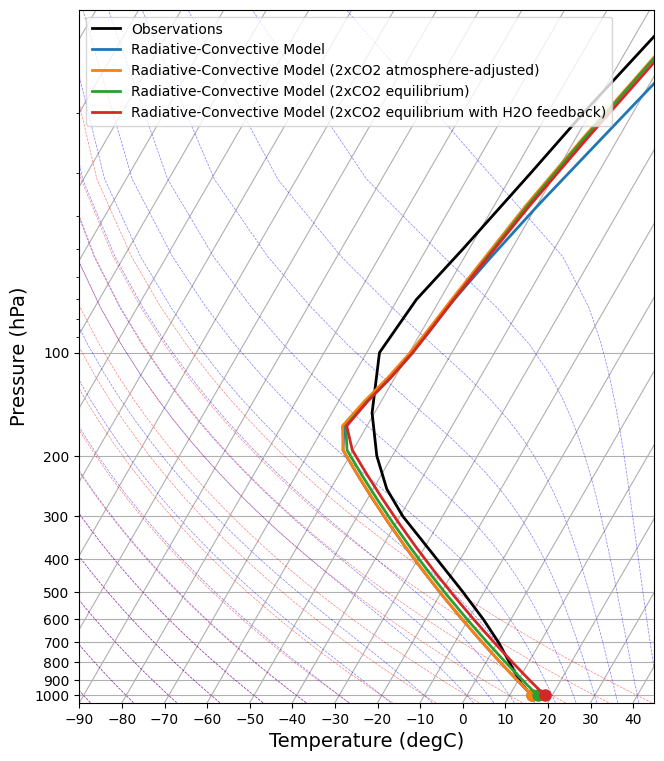

In [31]:
skew = make_skewT()
add_profile(skew, rcm)
add_profile(skew, rcm_2xCO2_adjusted)
add_profile(skew, rcm_2xCO2_eq)
add_profile(skew, rcm_2xCO2_h2o)

이 새로운 모델의 평형 기후 민감도(Equilibrium Climate Sensitivity)는 얼마인가요?

In [32]:
ECS = rcm_2xCO2_h2o.Ts - rcm.Ts
ECS

Field([2.98902357])

수증기 피드백(water vapor feedback)을 고려하면, 이산화탄소(CO$_2$) 농도가 두 배 증가할 때 피드백이 없을 때의 민감도(no-feedback sensitivity)인 1.3 K가 아닌 평형(equilibrium) 상태에서 3 K의 온난화가 발생합니다.

상당히 큰 차이입니다!

시스템 이득은 비율입니다

In [33]:
g = ECS / ECS_nofeedback
g

Field([2.29951722])

따라서, 대기 습윤화는 지구 온난화 효과를 두 배 이상 증가시킵니다.

## 6. 개별 되먹임 과정이 평형 기후 민감도(Equilibrium Climate Sensitivity)에 미치는 기여

### 다양한 되먹임 효과 합산하기

이제 여러 개별 되먹임 과정들이 동시에 발생한다면 어떻게 될까요?

우리는 각각이 물리적으로 구별되는 메커니즘(예: 수증기, 지표면의 눈과 얼음, 구름 변화, 기온 감률 효과 등)을 나타내는 개별 되먹임량 $f_1, f_2, f_3, ...$을 고려할 수 있습니다.

각 개별 과정은 출력의 $f_i$ 비율을 가져와 입력에 더합니다. 따라서 피드백(feedback) 양은 가산적(additive)입니다.

$$ f = f_1 + f_2 + f_3 + ... = \sum_{i=0}^N f_i $$

이는 개별 피드백 과정의 중요성을 비교할 수 있는 방법을 제공합니다!

기후 민감도는 이제 다음과 같습니다.

$$ \Delta T_{2xCO2} = \frac{1}{1- \sum_{i=0}^N f_i } \Delta T_0 $$

따라서 기후 민감도는 **양의 피드백 과정(positive feedback processes)에 의해 증가하고**, **음의 피드백 과정(negative feedback processes)에 의해 감소합니다**.

### 기후 피드백 매개변수

우리는 이것을 원래의 복사 강제력(radiative forcing)을 이용하여 다음과 같이 쓸 수도 있습니다:

$$ \Delta T_{2xCO2} = \frac{\Delta R}{\lambda_0 - \sum_{i=1}^{N} \lambda_i} $$

여기서

$$ \lambda_i = \lambda_0 f_i $$

이는 **기후 피드백 매개변수**라고 알려져 있으며, 단위는 W m$^{-2}$ K$^{-1}$입니다.

이러한 부호 규칙(sign conventions)을 선택하면, 양의 피드백(positive feedback) 과정에 대해 $\lambda_i > 0$이 됩니다.

개별 피드백 매개변수 $\lambda_i$는 가산적(additive)이며, 무피드백 매개변수 $\lambda_0$와 비교될 수 있습니다.

우리는 예를 들어 순 기후 피드백(net climate feedback)을 다음과 같이 분해할 수 있습니다.

- 장파 및 단파 과정
- 구름 및 비구름 과정

이러한 개별 피드백 과정들은 양성일 수도 있고 음성일 수도 있습니다. 이는 매우 강력한 방법인데, 그 이유는 우리가 그들의 $\lambda_i$ 값들을 단순히 비교함으로써 **다양한 피드백 과정들의 상대적 중요성**을 측정할 수 있기 때문입니다.

### 모든 기후 모델에는 플랑크 피드백이 존재합니다

우리의 무피드백 반응 매개변수 $\lambda_0$는 종종 **플랑크 피드백 (Planck feedback)**이라고 불립니다.

이것은 엄밀히 말해 피드백이 아닙니다. 이는 가장 기본적인 보편적 기후 과정이며, 모든 기후 모델에 존재합니다. 이는 단순히 따뜻한 행성이 차가운 행성보다 우주로 더 많은 에너지를 복사한다는 사실을 나타내는 것입니다.

우리가 살펴보겠지만, 우리의 $\lambda_0 = 3.3 ~\text{W} ~\text{m}^{-2} ~\text{K}^{-1} $ 추정치는 복잡한 GCM (General Circulation Models)에서 진단된 플랑크 피드백 (Planck feedback)과 본질적으로 동일합니다. 대부분의 기후 모델 (그리고 실제 기후 시스템)은 다른 복사 피드백 과정들을 가지고 있으며, 그 결과

$$\lambda = \lambda_0 - \sum_{i=1}^{N} \lambda_i \ne \lambda_0 $$

### 우리의 단일 열 모델(single-column model)에서 피드백 매개변수(feedback parameters) 계산

우리는 수증기 피드백(water vapor feedback)을 포함하는 우리 모델에서 피드백 매개변수(feedback parameter)를 쉽게 계산할 수 있습니다.

이는 복사 강제력(radiative forcing) $\Delta R$과 기후 민감도(climate sensitivity)의 비율에 불과합니다:

In [34]:
lambda_net = DeltaR_adjusted / ECS
lambda_net

Field([1.4101219])

순 피드백은 $\lambda = 1.43$ W m$^{-2}$ K$^{-1}$ 입니다.

피드백의 가산성(additive nature) 때문에, 이는 수증기 피드백의 개별적인 기여도가 다음과 같다는 것을 의미합니다.

$$ \lambda_{h2o} = \lambda_0 - \lambda $$

In [35]:
lambda_h2o = lambda0 - lambda_net
lambda_h2o

Field([1.83247769])

따라서 우리는 $\lambda_{h2o} = 1.8$ W m$^{-2}$ K$^{-1}$의 수증기 피드백을 측정합니다.

이는 수증기 피드백의 **증폭 효과**와 일치하는 **양수**입니다.

이 값의 물리적 의미:

**지표면 온도가 1도 상승할 때마다, 증가된 수증기 온실 효과는 추가적으로 1.86 W m$^{-2}$의 복사 강제력(Radiative Forcing)을 제공합니다.**

## 7. 복잡 기후 모델에서 진단된 피드백

### IPCC AR5 보고서의 데이터

이 그림은 IPCC AR5 보고서 {cite:p}`AR5_Ch9`에서 재현된 것입니다. 이는 해당 평가에 기여한 다양한 모델에서 진단된 피드백들을 보여줍니다.

(학기 후반에 피드백 진단이 실제로 어떻게 이루어지는지 논의할 것입니다)

전체 인용 정보는 아래를 참조하세요.

![피드백 AR5](https://www.ipcc.ch/site/assets/uploads/2018/02/Fig9-43-1.jpg)

**그림 9.43** | (a) Soden et al. (2008)의 방법을 따라 Soden and Held (2006)와 Vial et al. (2013)에서 인용한, CMIP3 및 CMIP5 모델(각각 기호의 왼쪽 및 오른쪽 열)에 대한 개별 되먹임(플랑크 (P), 수증기 (WV), 구름 (C), 반사율 (Albedo, A), 기온 감률 (Lapse Rate, LR), 수증기와 기온 감률의 조합 (WV+LR), 그리고 플랑크를 제외한 모든 되먹임의 합 (ALL))의 강도. CMIP5 되먹임은 CO2 농도가 급격히 4배 증가하는(4 × CO2) CMIP5 시뮬레이션에서 도출되었다. (b) Andrews et al. (2012)가 회귀 기법을 사용하여 얻은 평형 기후 민감도 (ECS, Equilibrium Climate Sensitivity)를 CO2 유효 복사 강제력 (Effective Radiative Forcing, ERF)과 모든 되먹임의 합의 비율로부터 추정된 ECS와 비교한 그림. CO2 ERF는 Andrews et al. (2012)의 4 × CO2 강제력의 절반 값이며, 총 되먹임 (ALL + 플랑크)은 Vial et al. (2013)의 자료를 사용했다.

*이 그림 설명은 AR5 WG1 보고서 {cite:p}`AR5_Ch9`에서 발췌되었다.*

범례:

- P: 플랑크 되먹임
- WV: 수증기 되먹임
- LR: 기온 감률 되먹임
- WV+LR: 수증기 및 기온 감률 복합 되먹임
- C: 구름 되먹임
- A: 표면 알베도 되먹임
- ALL: 플랑크 되먹임을 제외한 모든 되먹임의 합, 즉 ALL = WV+LR+C+A

주목할 사항:

- 모든 모델들은 플랑크 되먹임 (Planck feedback)에 대해 강하게 동의합니다.
- 플랑크 되먹임은 우리의 $\lambda_0$ 추정치와 마찬가지로 약 $-3.2 ~\text{W} ~\text{m}^{-2} ~\text{K}^{-1} $ 입니다 (단, 부호 규약은 반대입니다. 문헌에서 이 점을 주의 깊게 살펴보세요).
- 수증기 되먹임 (water vapor feedback)은 모든 모델에서 강한 양의 되먹임입니다.
- 기온 감률 되먹임 (lapse rate feedback)은 나중에 다룰 내용입니다. 이는 약간 음의 되먹임입니다.
- 나중에 논의할 이유들 때문에, 수증기 되먹임을 측정하는 가장 좋은 방법은 기온 감률 되먹임과 결합하는 것입니다.
- 모델들은 결합된 수증기 및 기온 감률 되먹임에 대해 강하게 동의합니다.

- 알베도 피드백(albedo feedback)은 약간 양의 값이지만, 전 지구적으로는 상당히 작습니다.
- 모델들 간의 가장 큰 편차(spread)는 단연코 구름 피드백(cloud feedback)에서 발생합니다.
- 모델들 간의 전 지구적 구름 피드백은 약간 음의 값에서부터 강하게 양의 값까지 분포합니다.
- 전체 피드백에서의 편차 대부분은 구름 피드백에서의 편차로 인해 발생합니다.
- 따라서, 모델들 간의 평형 기후 민감도(Equilibrium Climate Sensitivity, ECS) 편차 대부분은 구름 피드백에서의 편차로 인한 것입니다.

우리의 단일 열 모델에서 계산했던 피드백 매개변수들을 다시 살펴보세요. 이 그림의 데이터와 그것들은 어떻게 비교되나요?

## 크레딧

이 노트북은 Albany 대학교의 [Brian E. J. Rose](https://www.atmos.albany.edu/facstaff/brose/)가 개발하고 관리하는 오픈 소스 교재인 [The Climate Laboratory](https://brian-rose.github.io/ClimateLaboratoryBook)의 일부입니다.

본 자료는 [크리에이티브 커먼즈 저작자표시 4.0 국제 (CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/) 라이선스에 따라 무료 및 공개 이용이 허가되어 있습니다.

본 자료와 [climlab 소프트웨어](https://github.com/climlab/climlab)의 개발은 Brian Rose에게 수여된 AGS-1455071 과제 번호에 따라 미국 국립과학재단(National Science Foundation)의 부분적인 지원을 받았습니다. 여기에 표현된 모든 의견, 연구 결과, 결론 또는 권고는 저의 것이며, 반드시 미국 국립과학재단(National Science Foundation)의 견해를 반영하는 것은 아닙니다.